In [15]:

%reload_ext autoreload
%autoreload 2
%matplotlib widget
from pathlib import Path
import os, sys

project_root = Path.cwd()
if not (project_root / "src").exists():
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

data_dir = project_root / "data"

import pandas as pd

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.transforms import Affine2D
from mpl_toolkits.axisartist.parasite_axes import HostAxes
import ipywidgets as widgets
from IPython.display import display, clear_output
from ipywidgets import interact, interactive
from tqdm.notebook import tqdm
import itertools
import multiprocess as mp
from functools import partial
from src.algorithms import estimators
from src.helpers import stats_utils, data_utils, sim_utils

### Create line spacings

In [16]:
linespacing_depth = sim_utils.create_spacing_by_depth(mean=63, multiplier=6, res=8)
linespacing_wanted = [80, 128, 256, 512, 1024]
linespacing_meters = sim_utils.create_combined_spacings(spacing_by_depth=linespacing_depth, spacing_wanted=linespacing_wanted, minimum_spacing=80)
linespacing_meters = [128]

In [17]:
# select the dataset to analyze
list1 = ['Testbed2.tif']
seabed = 'Testbed2'

# window size multiples to use for the analysis (1 = 1x, 2 = 2x, etc. default is 1)
window_multiples = [1]

# set the estimators and methods to use for the analysis
fxn_list = [estimators.spectral_estimator, estimators.statistical_estimator]
fxn_methods = ['PSD99', 'SER']
if_fft_list = [True, False]
method_list = list(zip(fxn_list, fxn_methods, if_fft_list))

# sampling_methods = ['both','right','left'] #use same if the sampling is same location
sampling_methods = ['both']

# residual as a percent of depth or in meters
normalize_residual = [True]

# bootstap for pass coverage CI
bootstrap = [True]

settings_list = list(itertools.product(list1, linespacing_meters, window_multiples, method_list, sampling_methods, normalize_residual, bootstrap))
len(settings_list)

# export
outdir = project_root / 'results'

# ensure output directory exists and pass as string to avoid Path/formatting issues
outdir.mkdir(parents=True, exist_ok=True)

In [18]:
partial_run = partial(sim_utils.single_run_orthogonal, data_dir=data_dir)

def run_simulation(settings:list, tiled:bool=False,) -> list:
    results = []
    p = mp.Pool(processes=mp.cpu_count())
    with p:
        results = p.map(partial_run, settings)

    return results

### Estimate uncertainty

In [19]:
results = run_simulation(settings=settings_list)

In [20]:
path = f'{outdir}/{seabed}_multi_statistical_comparison.xlsx'
df_results, outpath = stats_utils.export_uncertainty_results(results=results, csv_path=path, sort_by="linespacing", bootstrap=bootstrap[0])

Results exported to: c:\Users\eadediran\vscode\iBLUE\results/Testbed2_multi_statistical_comparison.xlsx


### Pass Coverage Plot with 95% Bootstrap CI

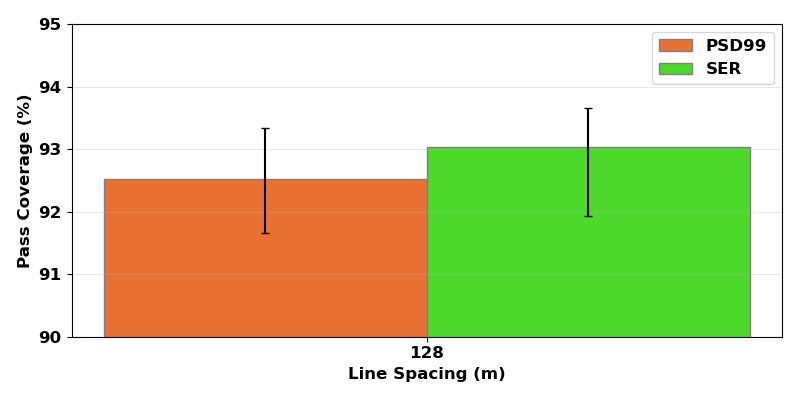

[WindowsPath('c:/Users/eadediran/vscode/iBLUE/results/Testbed2_multi_pass coverages.png')]

In [21]:
sim_utils.plot_pass_by_method_grouped_spacing(df=df_results,outdir=outdir,pass_percent=0)

## Weighted Composite Score

In [22]:
feature_cols = ['rmse_s', 'bias_s','severity_score_s', 'over_penalty_s']
base_weights = {'rmse_s':0.4, 'bias_s':0.3, 'severity_score_s':0.25, 'over_penalty_s':0.05}
sweep_ranges = {'rmse_s': (0.25, 0.65, 10),
                'bias_s': (0.15, 0.5, 10),
                'severity_score_s': (0.05, 0.3, 10),
                'over_penalty_s': (0.02, 0.12, 10),}
# name = 'rmsebiassevover_nocorrmae'

pass_thresholds = [90]
for pass_threshold in pass_thresholds:
    path = f'{outdir}/{seabed}_multi_single_weight_composite_{pass_threshold}%_coverage.xlsx'
    df_norm, weights_dict, summary, summary_spacing, best_spacing, best_sampling_spacing = sim_utils.composite_score(df=df_results,weights=base_weights,group_cols=['Seabed', 'Method', 'Sampling'],path=path,expected_cols=None,pass_threshold=pass_threshold)
    path = f'{outdir}/{seabed}_multi_weights_sweep_composite_{pass_threshold}%_coverage.xlsx'
    results_df, best_methods_df = sim_utils.systematic_weight_sweep(df_norm, feature_cols, base_weights, sweep_ranges,
                                                      top_k=3, out_prefix=path, groupby_cols=['Spacing','Method','Sampling'], compare_ml=False)

Total sweep points: 10000
Processed 500/10000 sweep points...
Processed 1000/10000 sweep points...
Processed 1500/10000 sweep points...
Processed 2000/10000 sweep points...
Processed 2500/10000 sweep points...
Processed 3000/10000 sweep points...
Processed 3500/10000 sweep points...
Processed 4000/10000 sweep points...
Processed 4500/10000 sweep points...
Processed 5000/10000 sweep points...
Processed 5500/10000 sweep points...
Processed 6000/10000 sweep points...
Processed 6500/10000 sweep points...
Processed 7000/10000 sweep points...
Processed 7500/10000 sweep points...
Processed 8000/10000 sweep points...
Processed 8500/10000 sweep points...
Processed 9000/10000 sweep points...
Processed 9500/10000 sweep points...
Processed 10000/10000 sweep points...
Saved Excel file: c:\Users\eadediran\vscode\iBLUE\results/Testbed2_multi_weights_sweep_composite_90%_coverage.xlsx
